In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency


In [13]:

df = pd.read_csv('Clean_Dataset.csv')


TEST ANOVA

In [14]:


groups = [group["price"].values for name, group in df.groupby("airline")]
f_stat, p_value = f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_value)
alpha = 0.05

if p_value < alpha:
    print("On rejette H0 : il existe une différence significative entre les compagnies aériennes.")
else:
    print("On ne peut pas rejeter H0 : il n’y a pas de différence significative.")


F-statistic: 17194.402096092468
p-value: 0.0
On rejette H0 : il existe une différence significative entre les compagnies aériennes.


TEST T-TEST

In [15]:
from scipy.stats import ttest_ind
group1 = df[df["class"] == "Economy"]["price"]
group2 = df[df["class"] == "Business"]["price"]
t_stat, p_value = ttest_ind(group1, group2)

alpha = 0.05

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("On rejette H0 : il existe une différence significative entre les deux classes")
else:
    print("On ne peut pas rejeter H0 : pas de différence significative")

t-statistic: -1480.683826786644
p-value: 0.0
On rejette H0 : il existe une différence significative entre les deux classes


<Axes: xlabel='days_left', ylabel='Percent'>

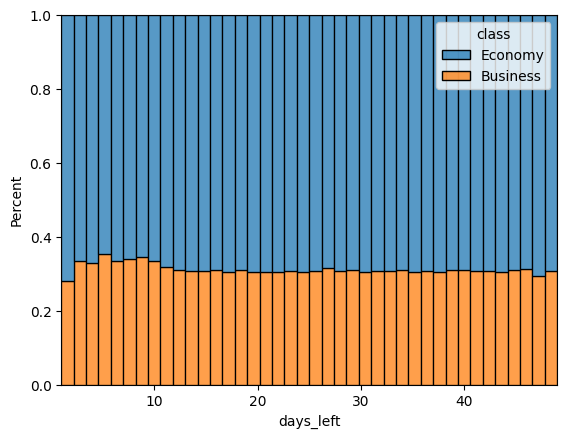

In [16]:
sns.histplot(
    data=df,
    x='days_left',
    hue='class',
    bins=40,
    multiple='fill',
    stat='percent'
)

H0: the variable class(Economy,Buisness) does not depent on the days left after reservation moment

In [17]:
contengency = pd.crosstab(df['class'],df['days_left'])
chi2 ,p , dof, expected = chi2_contingency(contengency)
print(p)

2.819153632455799e-76


In [18]:
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: variable class (Economy,Buisness) is dependent on the days left after reservation moment")
else:
    print("Fail to reject the null hypothesis: variables class and days_left are independent")

Reject the null hypothesis: variable class (Economy,Buisness) is dependent on the days left after reservation moment
